In [1]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy.stats import linregress, pearsonr, spearmanr, norm
from sklearn.metrics import roc_curve, auc
import time
import distinctipy

import glob
import re

import pickle as pkl
import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(current_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from nsm.nsm import *

# set plot parameters
params = {'legend.fontsize': 15,
          'figure.figsize': (7, 7),
          'axes.labelsize': 20,
          'axes.titlesize': 20,
          'axes.linewidth': 3,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'xtick.labelsize':18,
          'ytick.labelsize':18,
          'svg.fonttype':'none'}
plt.rcParams.update(params)
np.random.seed(12345)

In [2]:
mediators_ = {'mediators1': ['R01'], 
             'mediators2': ['R09'], 
             'mediators3': ['R01', 'R05'], 
             'mediators4': ['R01', 'R13'], 
             'mediators5': ['R01', 'R03', 'R07', 'R10', 'R13'], 
             'mediators6': ['R01', 'R03', 'R05', 'R07', 'R08', 'R09', 'R10', 'R12', 'R13', 'R15'], 
             'mediators7': ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15']}

sps = 12
species = ['S{:02d}'.format(i+1) for i in range(sps)]
rscs = 15
resources = ['R{:02d}'.format(i+1) for i in range(rscs)]
exps = 100
cs = 'baseline'
cplx = 'base'
md = 'mediators4'
mediators = mediators_[md]
k = 1
variables = species + mediators
md_indx = [resources.index(m) for m in mediators]

df = pd.read_csv(f"datasets/data_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{k}.csv")
df_test = pd.read_csv(f"datasets/data_{sps}s{rscs}r_{cplx}_{cs}_test.csv")
for exp_name, exp_df in df_test.groupby("Treatments"):
    if np.all(exp_df.loc[exp_df['Time']==0,exp_df.columns.str.contains('S')].isna()) or exp_df.loc[exp_df['Time']==0,exp_df.columns.str.contains('S')].values[0].sum() == 0:
        df_test = df_test[df_test.Treatments != exp_name]

with open(f'models/model_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.pkl', 'rb') as f:
      model = pkl.load(f)

w = np.array([1] + 4*[0.7] + 3*[0.5] + 2*[0.7] + 2*[0.4] + 3*[0.5])
l = np.array([0.7] * 15)

c_iα = pd.read_csv(f'parameters/consumer_preference_{sps}s{rscs}r_{cplx}.csv', index_col=0)
sp_map = {'S{:01d}'.format(i): 'S{:02d}'.format(i+1) for i in range(sps)}
rcs_map = {'R{:01d}'.format(i): 'R{:02d}'.format(i+1) for i in range(rscs)}
rpl_map = {**sp_map, **rcs_map}
c_iα.columns = c_iα.columns.to_series().replace(rpl_map)
c_iα.index = c_iα.index.to_series().replace(rpl_map)
D_iαβ = np.load(f'parameters/metabolic_matrix_{sps}s{rscs}r_{cplx}.npy')
P_iαβ = (l * w) * c_iα.values[:, np.newaxis, :] * D_iαβ

C_iα = c_iα.loc[species, mediators]
P_iα = pd.DataFrame((P_iαβ.sum(axis=2)/ w)[:, md_indx], columns=mediators, index=species)

In [3]:
pred_dfs = []
for exp_name, exp_df in df_test.groupby("Treatments"):
    
    # make sure comm_data is sorted in chronological order
    exp_df.sort_values(by='Time', ascending=True, inplace=True)

    # get initial condition and evaluation times
    t_span = exp_df.Time.values
    Y_m = exp_df.loc[:,species + mediators].values

    # predict
    s_pred, s_var, m_pred, m_var = model.predict(Y_m, t_span)

    # save dataframe with predictions
    df_pred = pd.DataFrame()
    df_pred["Treatments"] = [exp_name] * len(t_span)
    df_pred['Time'] = t_span
        
    # save mean
    df_pred[[f'E[{s}]' for s in species]] = s_pred
    for s in species:
        if np.all(df_pred[f'E[{s}]'].values == df_pred[f'E[{s}]'].values[0]):
            df_pred[f'E[{s}]'] = np.nan
    df_pred[[f'E[{m}]' for m in mediators]] = m_pred
    for m in mediators:
        if np.all(df_pred[f'E[{m}]'].values == df_pred[f'E[{m}]'].values[0]):
            df_pred[f'E[{m}]'] = np.nan
        
    # save variance
    df_pred[[f'V[{s}]' for s in species]] = s_var
    for s in species:
        if np.all(df_pred[f'V[{s}]'].values == df_pred[f'V[{s}]'].values[0]):
            df_pred[f'V[{s}]'] = np.nan
    df_pred[[f'V[{m}]' for m in mediators]] = m_var
    for m in mediators:
        if np.all(df_pred[f'V[{m}]'].values == df_pred[f'V[{m}]'].values[0]):
            df_pred[f'V[{m}]'] = np.nan
    # save the dataframe
    pred_dfs.append(df_pred)
# concatenate all dataframes
df_pred = pd.concat(pred_dfs, ignore_index=True)
df_pred.sort_values(by=['Treatments', 'Time'], inplace=True)
df_pred

df_copy = df_test.copy()
variables = species + mediators
for exp_name, exp_df in df_copy.groupby("Treatments"):
    for variable in variables:
        if np.all(exp_df[variable].values == exp_df[variable].values[0]):
            df_copy.loc[df_copy.Treatments == exp_name, variable] = np.nan
    if np.all(exp_df.loc[exp_df['Time']==0,exp_df.columns.str.contains('S')].isna()) or exp_df.loc[exp_df['Time']==0,exp_df.columns.str.contains('S')].values[0].sum() == 0:
        df_copy = df_copy[df_copy.Treatments != exp_name]

/tmp/ipykernel_146428/2245263680.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_pred = pd.concat(pred_dfs, ignore_index=True)


In [4]:
df_pred

,Treatments,Time,E[S01],E[S02],E[S03],E[S04],E[S05],E[S06],E[S07],E[S08],...,V[S05],V[S06],V[S07],V[S08],V[S09],V[S10],V[S11],V[S12],V[R01],V[R13]
0,W0026,0,0.750000,NaN,0.750000,NaN,NaN,NaN,NaN,0.750000,...,NaN,NaN,NaN,0.012349,NaN,0.002725,NaN,NaN,12.684490,0.000781
1,W0026,1,2.430903,NaN,3.990669,NaN,NaN,NaN,NaN,2.725730,...,NaN,NaN,NaN,0.175780,NaN,0.135147,NaN,NaN,0.041623,0.040075
2,W0026,2,3.003622,NaN,4.689484,NaN,NaN,NaN,NaN,2.563076,...,NaN,NaN,NaN,0.156463,NaN,0.128695,NaN,NaN,0.001436,0.068942
3,W0026,3,2.668725,NaN,3.653558,NaN,NaN,NaN,NaN,1.962136,...,NaN,NaN,NaN,0.091680,NaN,0.077140,NaN,NaN,0.000410,0.086392
4,W0026,4,2.175367,NaN,2.697572,NaN,NaN,NaN,NaN,1.470631,...,NaN,NaN,NaN,0.052733,NaN,0.046549,NaN,NaN,0.000213,0.098441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6988,W3998,2,1.540378,NaN,2.796793,1.235386,2.408488,1.713896,1.956177,1.061073,...,0.037000,0.022099,0.029451,0.025804,NaN,NaN,NaN,0.018157,0.000265,0.096215
6989,W3998,3,1.554804,NaN,2.801458,0.951750,1.850524,1.291041,1.474425,0.834636,...,0.023234,0.012761,0.017004,0.016133,NaN,NaN,NaN,0.014107,0.000129,0.123520
6990,W3998,4,1.394757,NaN,2.425020,0.713730,1.408842,0.966540,1.099384,0.633416,...,0.015198,0.007743,0.010504,0.009573,NaN,NaN,NaN,0.010136,0.000113,0.142998
6991,W3998,5,1.171410,NaN,1.954344,0.534554,1.076307,0.723580,0.823437,0.476873,...,0.010333,0.004975,0.007041,0.005693,NaN,NaN,NaN,0.007038,0.000109,0.156245


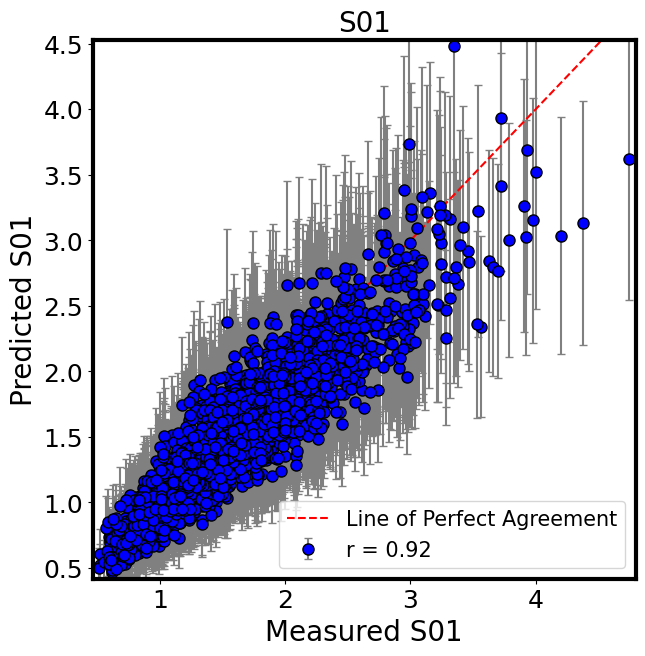

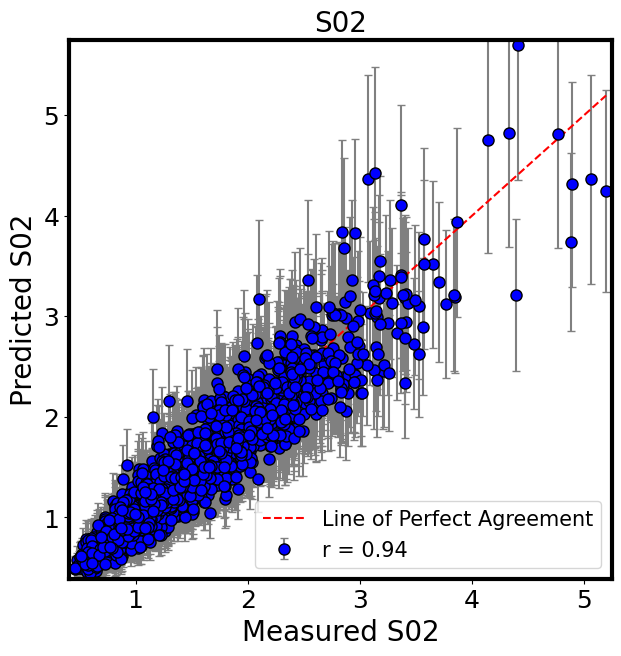

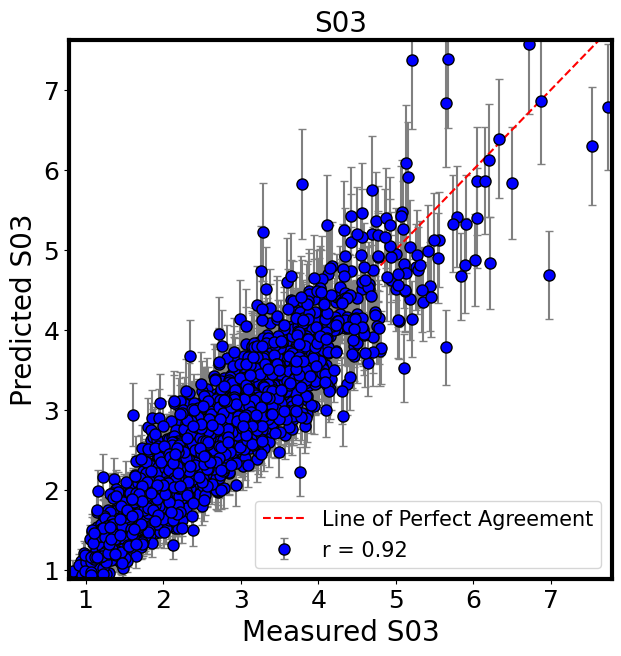

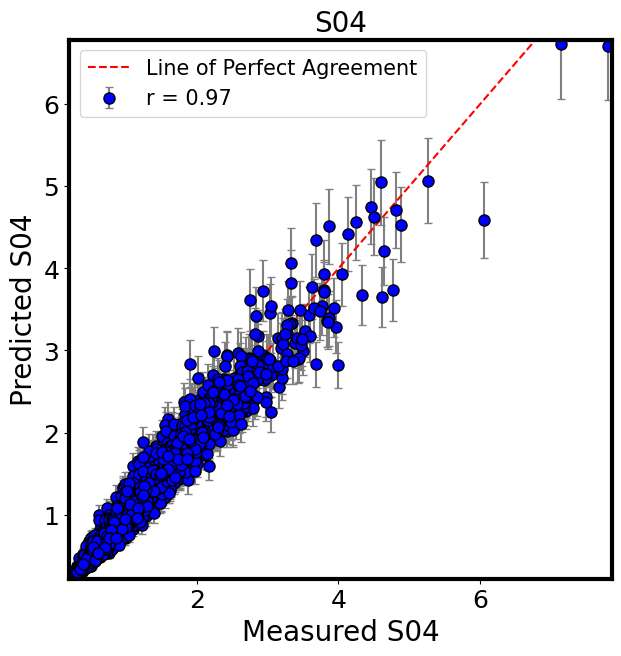

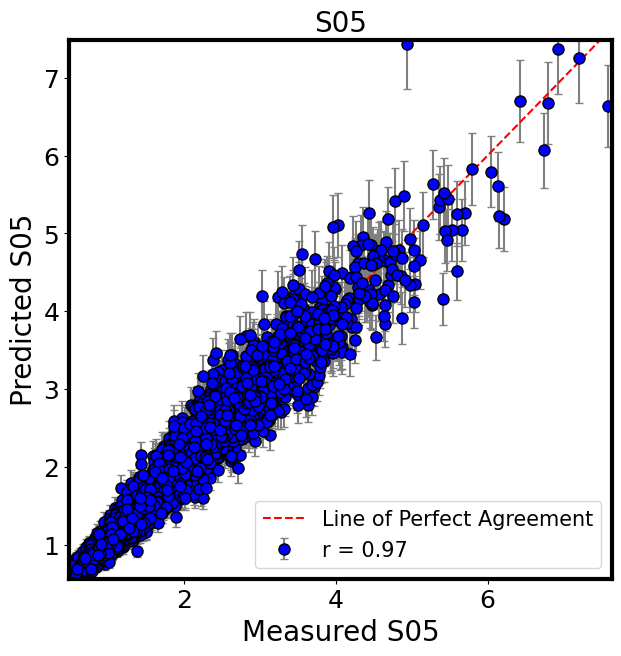

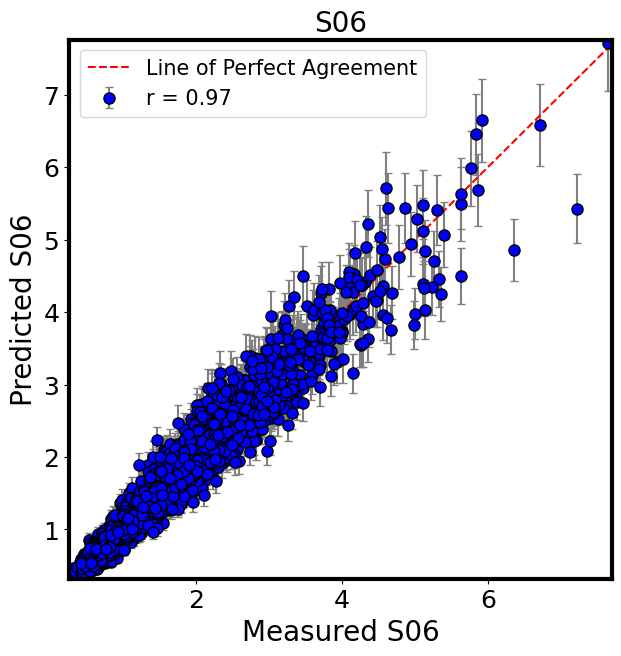

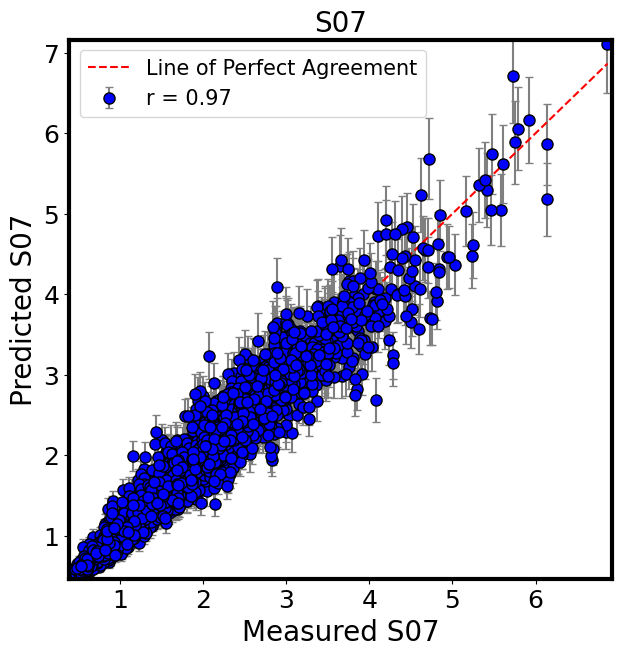

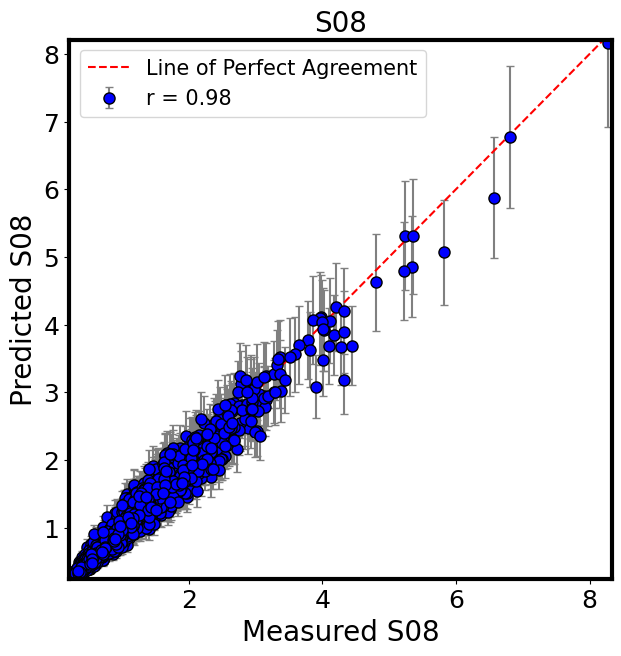

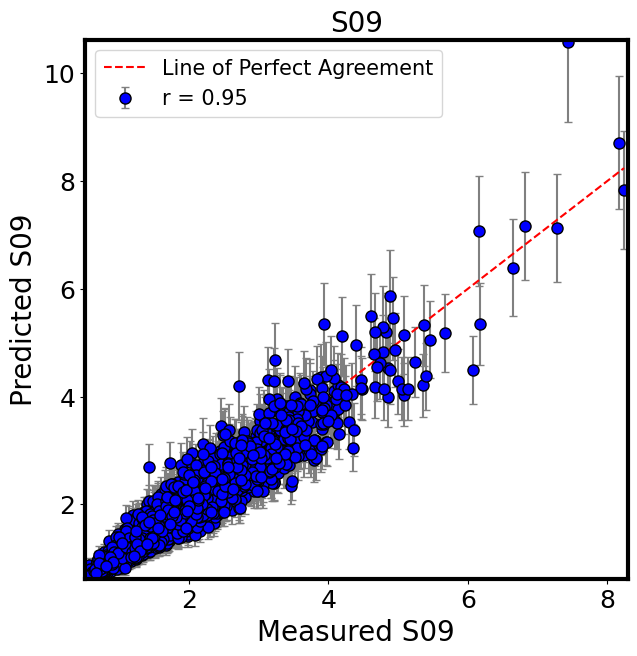

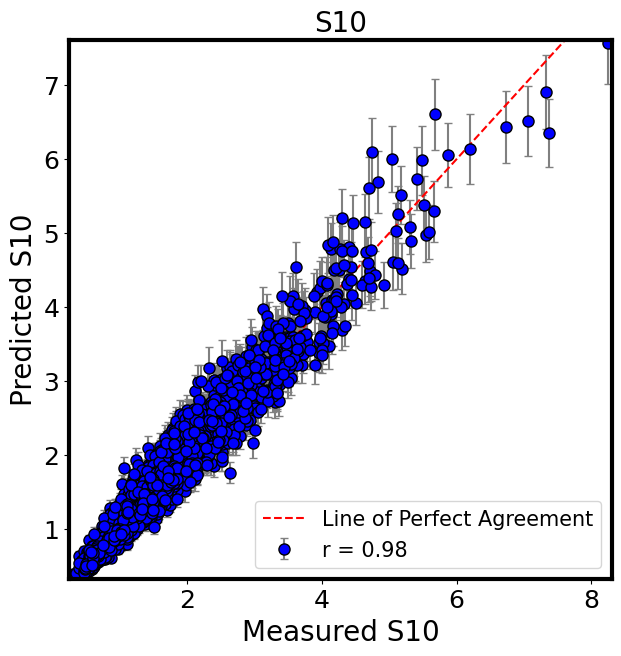

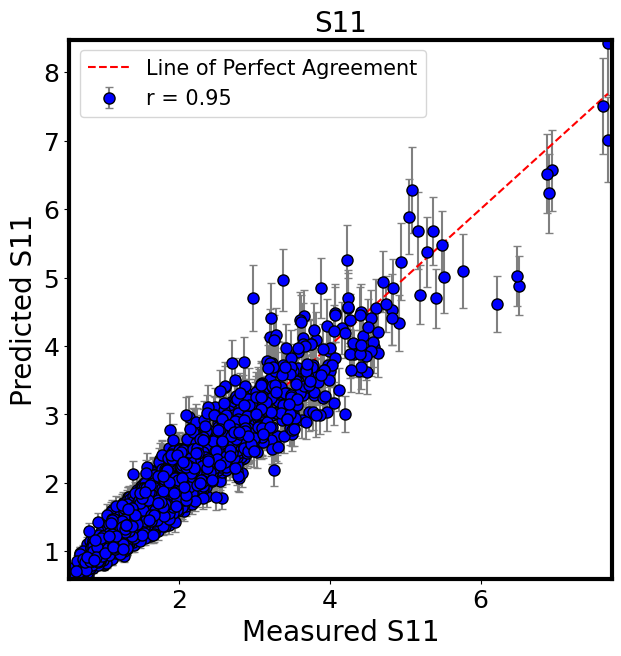

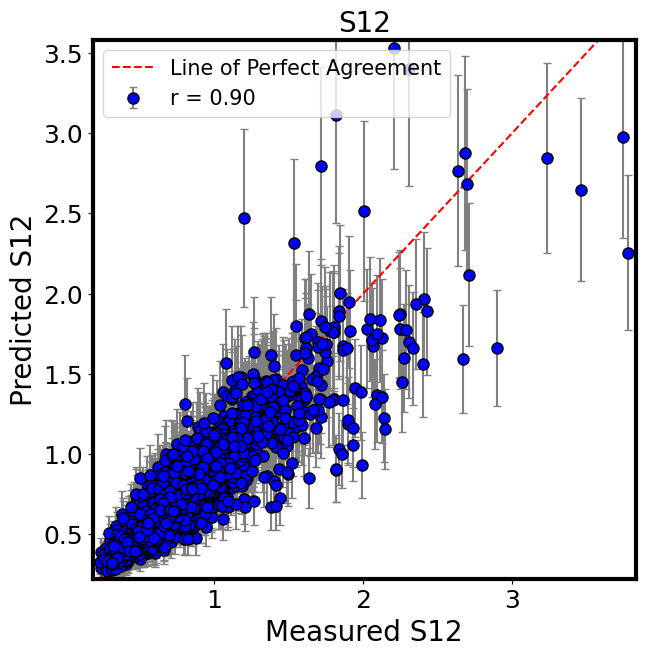

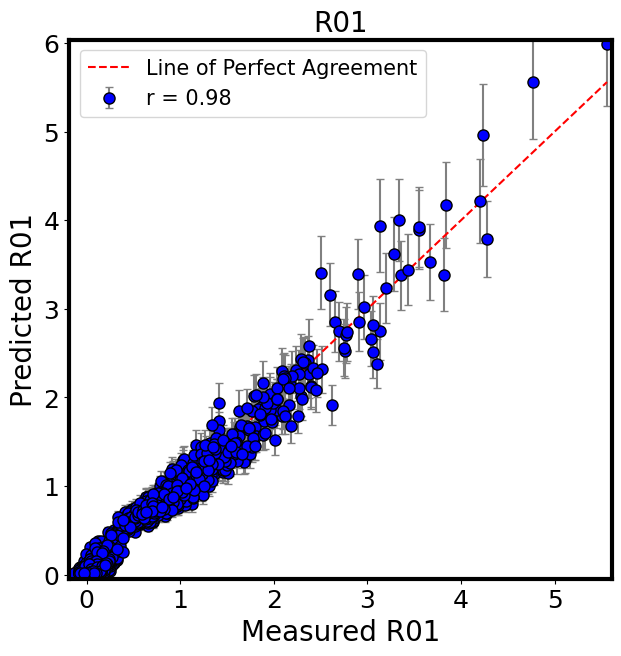

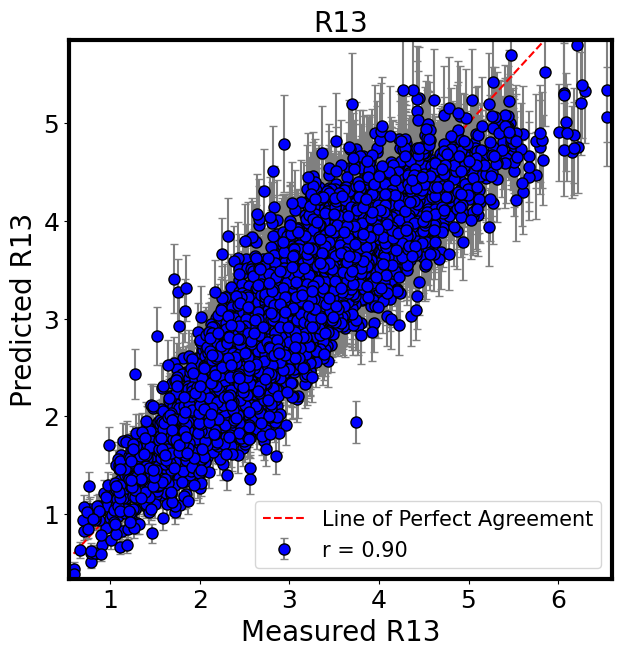

In [5]:
correlations = {
    'variable': [],
    'correlation': []
}
rsmes = {
    'variable': [],
    'rmse': []
}

for variable in species + mediators:
    measured_values = df_copy.loc[df_copy.Time > 0, variable].values
    measured_values = measured_values[~np.isnan(measured_values)]
    predicted_values = df_pred.loc[df_pred.Time > 0, f'E[{variable}]'].values
    predicted_values = predicted_values[~np.isnan(predicted_values)]
    predicted_errors = df_pred.loc[df_pred.Time > 0, f'V[{variable}]'].values ** 0.5
    predicted_errors = predicted_errors[~np.isnan(predicted_errors)]

    # Calculate Pearson correlation coefficient
    correlation, _ = pearsonr(measured_values, predicted_values)
    correlations['variable'].append(variable)
    correlations['correlation'].append(correlation)

    # calculate RSME
    rmse = np.sqrt(np.mean((measured_values - predicted_values) ** 2))
    rsmes['variable'].append(variable)
    rsmes['rmse'].append(rmse)

    # Plot the parity plot
    plt.errorbar(measured_values, predicted_values, yerr=predicted_errors,
                 fmt='o', color='blue', ecolor='gray', markersize=8, markeredgecolor='k', capsize=3)

    # Add line of perfect agreement
    plt.plot([min(measured_values), max(measured_values)],
             [min(measured_values), max(measured_values)],
             linestyle='--', color='red')

    # Add legend with Pearson correlation coefficient
    plt.legend(['Line of Perfect Agreement', f'r = {correlation:.2f}'])

    # Set labels and title
    plt.xlabel(f'Measured {variable}')
    plt.ylabel(f'Predicted {variable}')
    plt.title(f'{variable}')

    # Set plot limits
    plt.xlim(min(measured_values) - 0.05, max(measured_values) + 0.05)
    plt.ylim(min(predicted_values) - 0.05, max(predicted_values) + 0.05)
    # plt.savefig(f'plots/correlation-validations/validation_correlation_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k_{variable}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close()
correlations = pd.DataFrame(correlations)
rsmes = pd.DataFrame(rsmes)

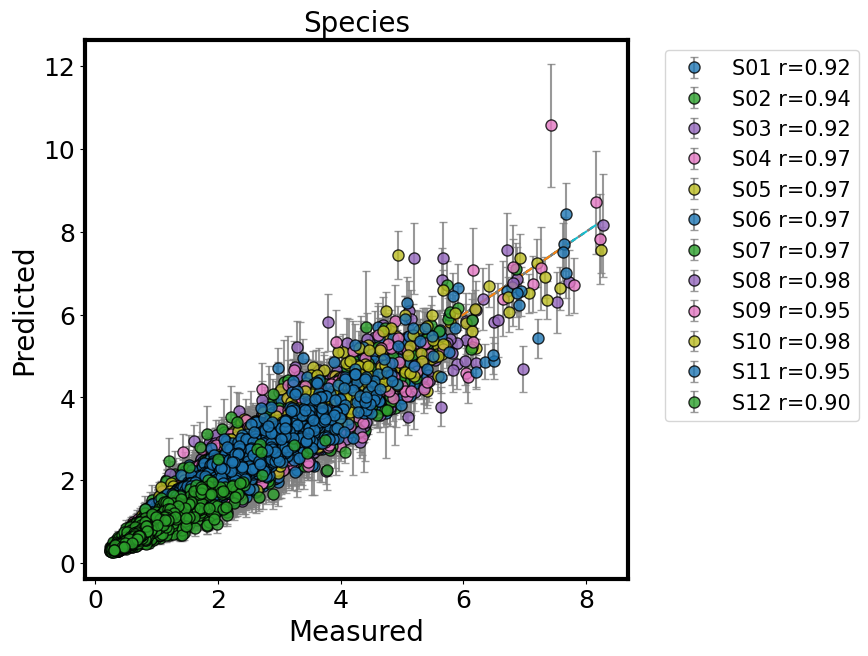

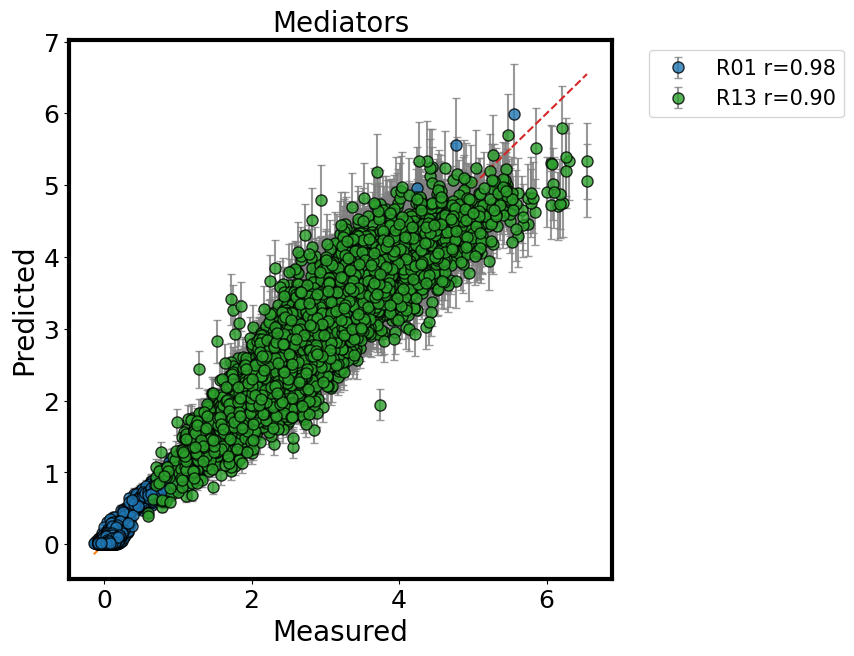

In [6]:
correlations = {
    'variable': [],
    'correlation': []
}
rsmes = {
    'variable': [],
    'rmse': []
}

for variable in species:
    measured_values = df_copy.loc[df_copy.Time > 0, variable].values
    measured_values = measured_values[~np.isnan(measured_values)]
    predicted_values = df_pred.loc[df_pred.Time > 0, f'E[{variable}]'].values
    predicted_values = predicted_values[~np.isnan(predicted_values)]
    predicted_errors = df_pred.loc[df_pred.Time > 0, f'V[{variable}]'].values ** 0.5
    predicted_errors = predicted_errors[~np.isnan(predicted_errors)]

    # Calculate Pearson correlation coefficient
    correlation, _ = pearsonr(measured_values, predicted_values)
    correlations['variable'].append(variable)
    correlations['correlation'].append(correlation)

    # calculate RSME
    rmse = np.sqrt(np.mean((measured_values - predicted_values) ** 2))
    rsmes['variable'].append(variable)
    rsmes['rmse'].append(rmse)

    # Plot the parity plot
    plt.errorbar(measured_values, predicted_values, yerr=predicted_errors,
                 fmt='o', ecolor='gray', markersize=8, markeredgecolor='k', capsize=3, label=f'{variable} r={correlation:.2f}', alpha=0.8)

    # Add line of perfect agreement
    plt.plot([min(measured_values), max(measured_values)],
             [min(measured_values), max(measured_values)],
             linestyle='--')

    # Add legend with Pearson correlation coefficient
    # plt.legend(['Line of Perfect Agreement', f'r = {correlation:.2f}'])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Set labels and title
    plt.xlabel(f'Measured')
    plt.ylabel(f'Predicted')
    plt.title(f'Species')

    # Set plot limits
    # plt.xlim(min(measured_values) - 0.05, max(measured_values) + 0.05)
    # plt.ylim(min(predicted_values) - 0.05, max(predicted_values) + 0.05)
    # plt.savefig(f'plots/correlation-validations/validation_correlation_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k_{variable}.svg', dpi=300, bbox_inches='tight')
plt.show()
    # plt.close()

for variable in mediators:
    measured_values = df_copy.loc[df_copy.Time > 0, variable].values
    measured_values = measured_values[~np.isnan(measured_values)]
    predicted_values = df_pred.loc[df_pred.Time > 0, f'E[{variable}]'].values
    predicted_values = predicted_values[~np.isnan(predicted_values)]
    predicted_errors = df_pred.loc[df_pred.Time > 0, f'V[{variable}]'].values ** 0.5
    predicted_errors = predicted_errors[~np.isnan(predicted_errors)]

    # Calculate Pearson correlation coefficient
    correlation, _ = pearsonr(measured_values, predicted_values)
    correlations['variable'].append(variable)
    correlations['correlation'].append(correlation)

    # calculate RSME
    rmse = np.sqrt(np.mean((measured_values - predicted_values) ** 2))
    rsmes['variable'].append(variable)
    rsmes['rmse'].append(rmse)

    # Plot the parity plot
    plt.errorbar(measured_values, predicted_values, yerr=predicted_errors,
                 fmt='o', ecolor='gray', markersize=8, markeredgecolor='k', capsize=3, label=f'{variable} r={correlation:.2f}', alpha=0.8)

    # Add line of perfect agreement
    plt.plot([min(measured_values), max(measured_values)],
             [min(measured_values), max(measured_values)],
             linestyle='--')

    # Add legend with Pearson correlation coefficient
    # plt.legend(['Line of Perfect Agreement', f'r = {correlation:.2f}'])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Set labels and title
    plt.xlabel(f'Measured')
    plt.ylabel(f'Predicted')
    plt.title(f'Mediators')

    # Set plot limits
    # plt.xlim(min(measured_values) - 0.05, max(measured_values) + 0.05)
    # plt.ylim(min(predicted_values) - 0.05, max(predicted_values) + 0.05)
    # plt.savefig(f'plots/correlation-validations/validation_correlation_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k_{variable}.svg', dpi=300, bbox_inches='tight')
plt.show()
    # plt.close()
correlations = pd.DataFrame(correlations)
rsmes = pd.DataFrame(rsmes)

In [7]:
correlations['Type'] = ['Species'] * len(species) + ['Mediators'] * len(mediators)
rsmes['Type'] = ['Species'] * len(species) + ['Mediators'] * len(mediators)

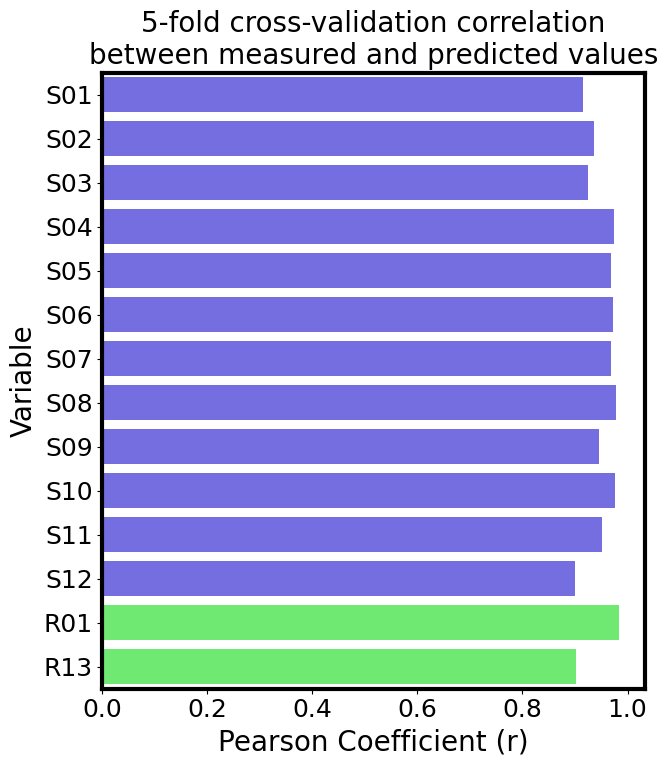

In [8]:
# Plot the correlation coefficients
plt.figure(figsize=(7, 8))
# colors = ['blue' if var in species else 'green' for var in correlations['variable']]
sns.barplot(y='variable', x='correlation', data=correlations, hue='Type', dodge=False, legend=False, palette=distinctipy.get_colors(2, pastel_factor=0.5))
plt.ylabel('Variable')
plt.xlabel('Pearson Coefficient (r)')
plt.title('5-fold cross-validation correlation\nbetween measured and predicted values')
# plt.xticks(rotation=90)
# plt.savefig(f'trouble-shooting/cv_correlation_barplot_{sps}s_15r_{md_cplx}.svg', dpi=300, bbox_inches='tight')
plt.show()

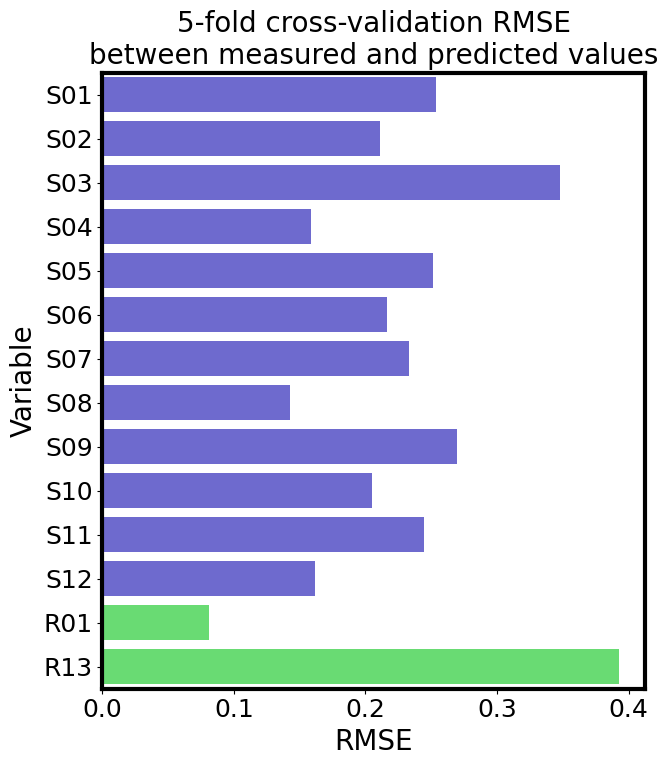

In [9]:
# Plot the RMSE
plt.figure(figsize=(7, 8))
# colors = ['blue' if var in species else 'green' for var in rsmes['variable']]
sns.barplot(y='variable', x='rmse', data=rsmes, hue='Type', dodge=False, legend=False, palette=distinctipy.get_colors(2, pastel_factor=0.5))
plt.ylabel('Variable')
plt.xlabel('RMSE')
plt.title('5-fold cross-validation RMSE\nbetween measured and predicted values')
# plt.xticks(rotation=90)
# plt.savefig(f'trouble-shooting/cv_rmse_barplot_{sps}s_15r_{md_cplx}.svg', dpi=300, bbox_inches='tight')
plt.show()

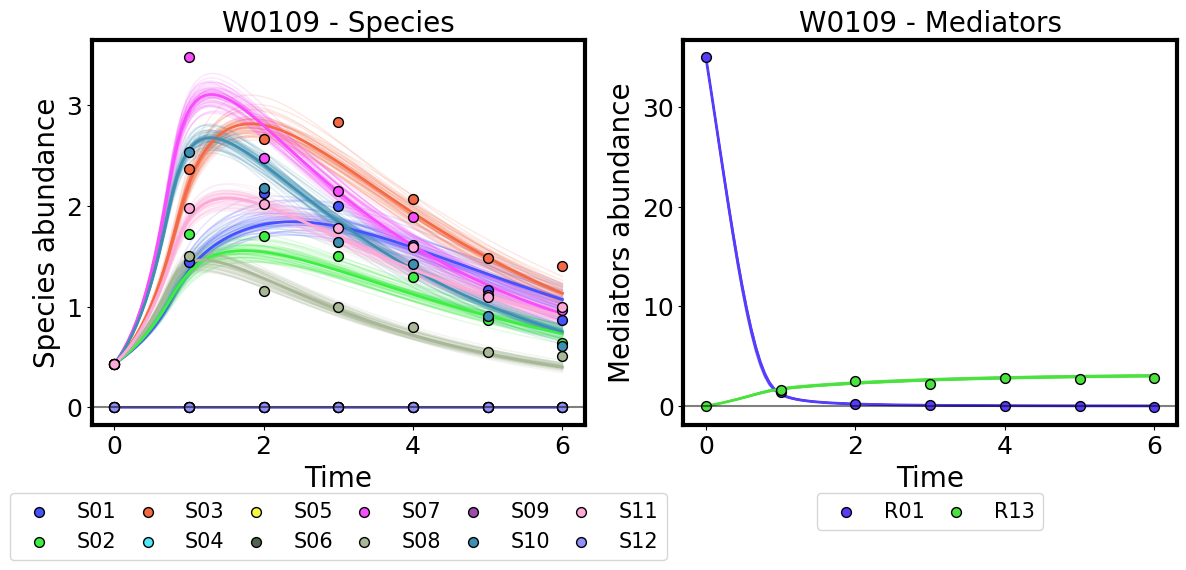

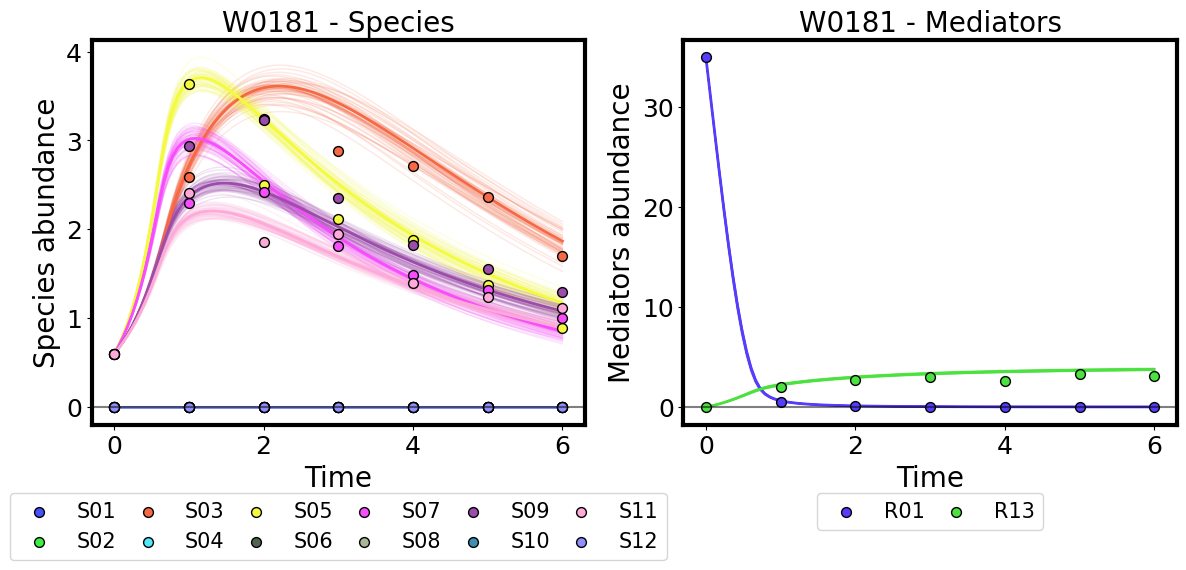

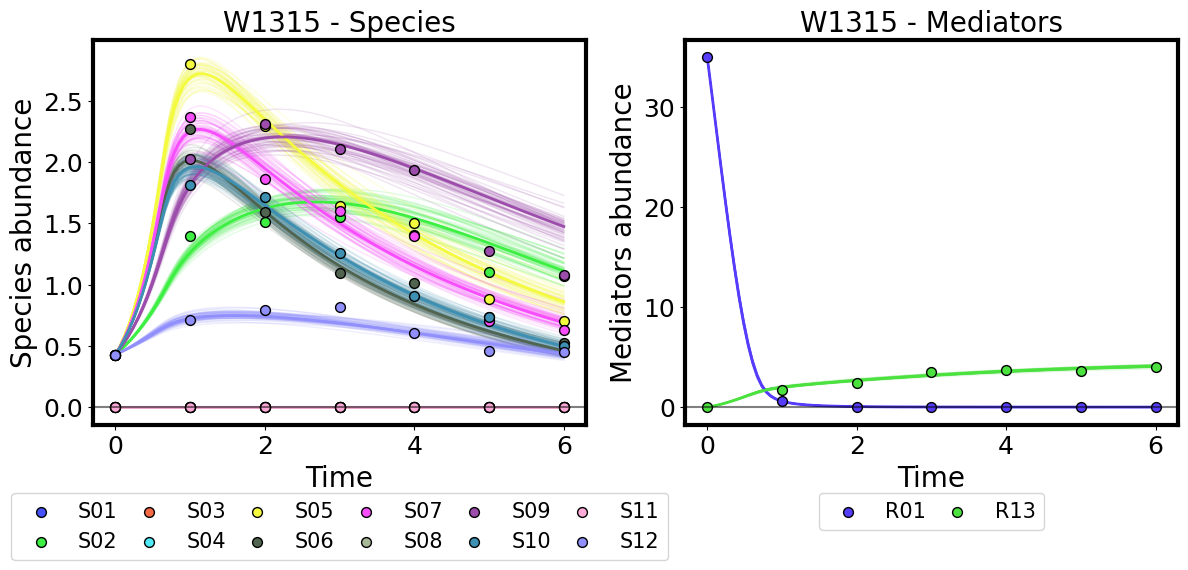

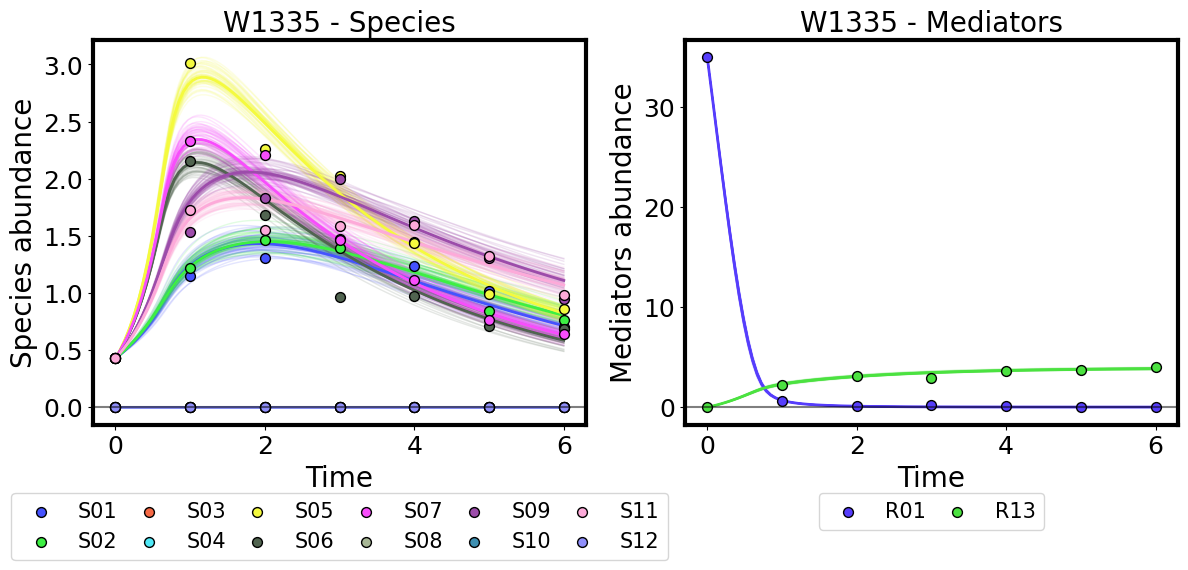

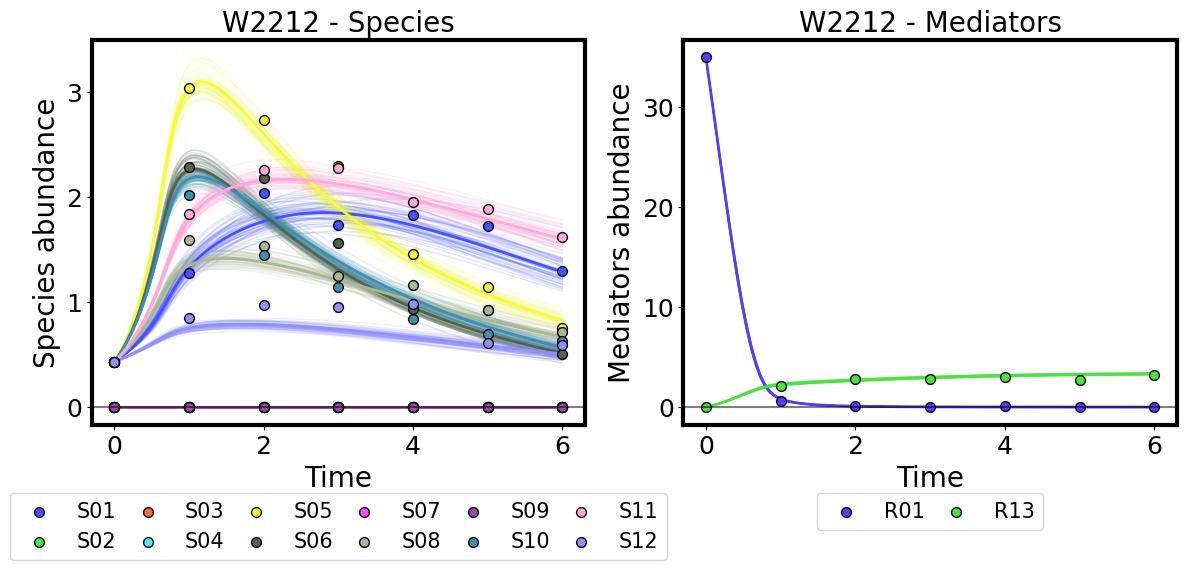

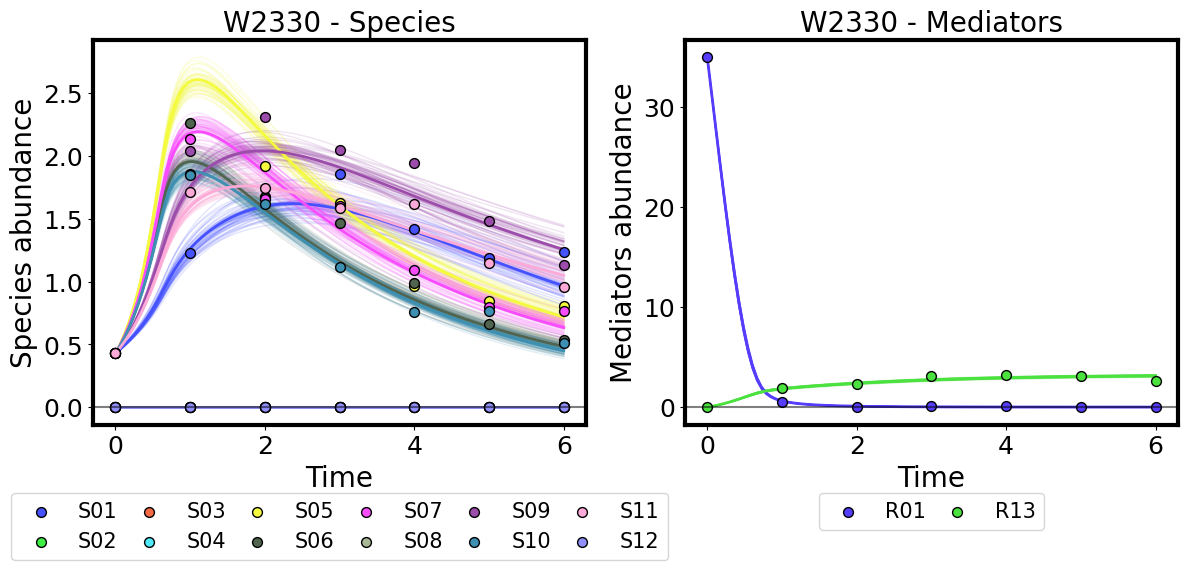

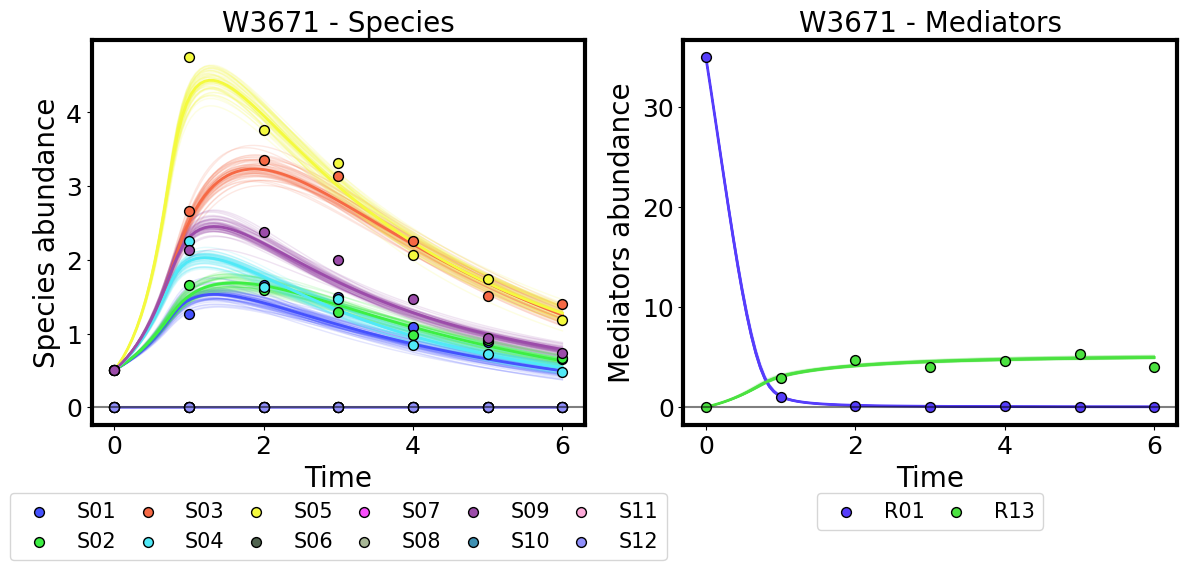

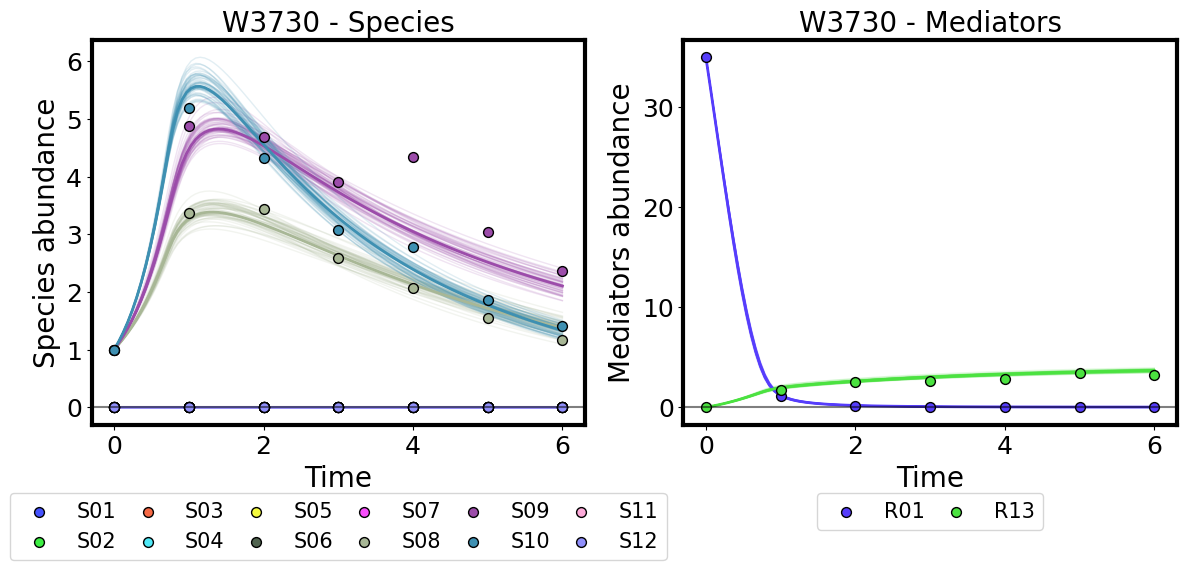

In [10]:
true = []
pred = []
spcs = []
colors_sps = distinctipy.get_colors(sps, pastel_factor=0.3)
colors_rscs = distinctipy.get_colors(rscs, pastel_factor=0.3)
for treatment, comm_data in df_test.groupby("Treatments"):
    if np.random.rand() > 1/exps:
        continue
    # make sure comm_data is sorted in chronological order
    comm_data.sort_values(by='Time', ascending=True, inplace=True)
    tspan = comm_data.Time.values

    # pull just the community data
    species_true = comm_data[species].values
    mediators_true = comm_data[mediators].values
    # input_vals = comm_data[inputs].values[0]
    output_true = np.concatenate((species_true, mediators_true), -1)

    # determine initial condition 
    s0 = species_true[0]
    r0 = mediators_true[0]
    x0 = np.concatenate((s0, r0))

    # increase teval
    # t_eval = np.linspace(0, tspan[-1] + 1, 100)
    t_eval = np.linspace(0, tspan[-1], 100)
    steps = len(t_eval)
    # generate posterior samples
    species_pred, mediators_pred = model.predict_sample(x0, 
                                                        t_eval, 
                                                        n_sample=50, 
                                                        # inputs=input_vals
                                                        )
    # compute summary statistics (mean and variance) of posterior predictive distribution
    E_species_pred, V_species_pred, E_mediators_pred, V_mediators_pred = model.predict(x0, 
                                                                                       t_eval, 
                                                                                       n_sample=100,
                                                                                    #    inputs=input_vals
                                                                                       )

    # concatenate species and mediator predictions
    output_pred = np.concatenate((species_pred, mediators_pred), -1)
    E_output_pred = np.concatenate((E_species_pred, E_mediators_pred), -1)
    V_output_pred = np.concatenate((V_species_pred, V_mediators_pred), -1)
        
    # predict end-point measured values
    true.append(species_true[-1])
    pred.append(species_pred[-1])
    spcs.append(species)

    # plot the results
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Plot species abundance
    for i, sp in enumerate(species):
        out_true = species_true[:,i]
        axs[0].scatter(tspan, out_true, color=colors_sps[i % len(colors_sps)], edgecolor='k', s=50, zorder=2, label=species[i])

        # plot posterior samples
        for out in species_pred:
             axs[0].plot(t_eval, out[:, i], color=colors_sps[i % len(colors_sps)], alpha=.15, zorder=0, linewidth=1)

        # plot mean of posterior 
        axs[0].plot(t_eval, E_species_pred[:,i], color=colors_sps[i % len(colors_sps)], linewidth=2, zorder=1)

    axs[0].axhline(y=0, linestyle='-', color='k', alpha=.5)
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Species abundance")
    axs[0].set_title(f"{treatment} - Species")
    axs[0].legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=6, columnspacing=0.5)

    # Plot mediators abundance
    for i, md in enumerate(mediators):
        out_true = mediators_true[:,i]
        axs[1].scatter(tspan, out_true, color=colors_rscs[i % len(colors_rscs)], edgecolor='k', s=50, zorder=2, label=mediators[i])

        # plot posterior samples
        for out in mediators_pred:
             axs[1].plot(t_eval, out[:, i], color=colors_rscs[i % len(colors_rscs)], alpha=.15, zorder=0, linewidth=1)

        # plot mean of posterior 
        axs[1].plot(t_eval, E_mediators_pred[:,i], color=colors_rscs[i % len(colors_rscs)], linewidth=2, zorder=1)

    axs[1].axhline(y=0, linestyle='-', color='k', alpha=.5)
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Mediators abundance")
    axs[1].set_title(f"{treatment} - Mediators")
    axs[1].legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=5, columnspacing=0.5)
    # plt.savefig(f'plots/fitted-trajectories/fitted_trajectories_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.svg', dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close()

In [11]:
def get_params(self, n_sample=500):

    # parameter names
    param_names = []

    # consumption rates
    for md in self.mediators:
        for sp in self.species:
            param_names += [md+"->"+sp]

    # production rates
    for md in self.mediators:
        for sp in self.species:
            param_names += [sp+"->"+md]

    # mediator degradation rate
    for md in self.mediators:
        param_names += [f"d({md})"]

    # sample parameters
    y = np.random.randn(n_sample, self.d)
    z = batch_T(self.shapes, y, self.lmbda)

    # init vector to store parameter samples
    params = np.zeros([n_sample, 2 * self.n_m * self.n_s + self.n_m])

    # transform and reshape parameters
    for i, z_i in enumerate(z):

        # transform / reshape parameters
        C_i, P_i, d_m, *rest = transform(reshape(self.shapes, z_i))
        params[i] = np.concatenate((C_i.ravel(), P_i.ravel(), d_m))

    # compute mean / stdv
    # C_mean = np.mean(C, 0).ravel()
    # C_stdv = np.std(C, 0).ravel()
    # P_mean = np.mean(P, 0).ravel()
    # P_stdv = np.std(P, 0).ravel()

    # save to dataframe
    param_df = pd.DataFrame()
    # param_df['Parameter'] = param_names
    # param_df['$\mu$'] = np.append(C_mean, P_mean)
    # param_df['$\sigma$'] = np.append(C_stdv, P_stdv)
    for i, param_name in enumerate(param_names):
        param_df[param_name] = np.array(params[:, i], float)

    return param_df

def gaussian_exceedance_prob(means, stds, threshold):
    """
    Computes the probability that each normally distributed variable
    (characterized by means and stds) exceeds the given threshold.
    
    Parameters:
    means (ndarray): A matrix of mean values.
    stds (ndarray): A matrix of standard deviations (must be the same shape as means).
    threshold (float): The threshold value.
    
    Returns:
    ndarray: A matrix of exceedance probabilities.
    """
    return 1 - norm.cdf((threshold - means) / stds)

def get_param_stats(self):

    # get mean and stdv
    mu = self.z
    sigma = np.exp(self.lmbda[self.d:])

    # mean and standard deviation of untransformed variables (real valued)
    C_mu, P_mu, d_mu, *rest = reshape(self.shapes, mu)
    C_s, P_s, d_s, *rest = reshape(self.shapes, sigma)
    
    # acceptance probabilities 
    C_pvals = gaussian_exceedance_prob(C_mu, C_s, -3.)
    P_pvals = gaussian_exceedance_prob(P_mu, P_s, -3.)
    d_pvals = gaussian_exceedance_prob(d_mu, d_s, -3.)
    
    # actual values passed through transform
    C = g(C_mu)
    P = g(P_mu)
    d = g(d_mu)
    
    return C, C_pvals, P, P_pvals 

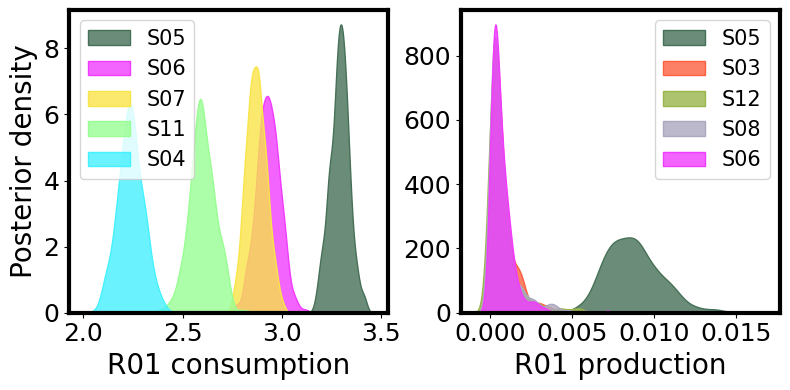

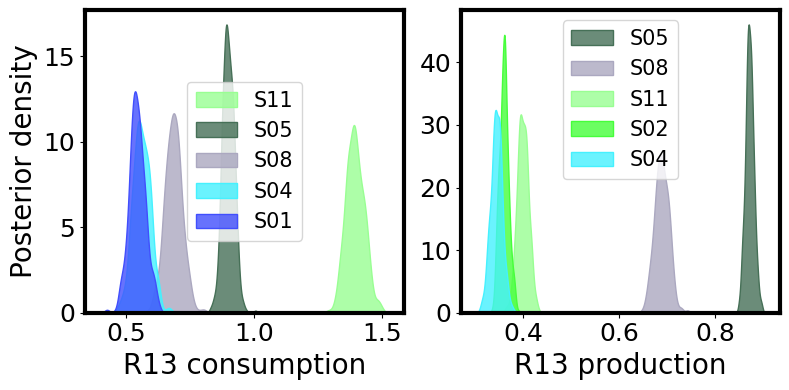

In [12]:
param_df = get_params(model)

# plot params for every mediator_complexity, experiments combination
# Define a custom color palette with distinct and vibrant colors
custom_colors = distinctipy.get_colors(sps, pastel_factor=0.3)

# Create a dictionary mapping each species to a unique color
species_color_dict = dict(zip(species, custom_colors))

for mediator in mediators:
    plt.figure(figsize=(8, 4))

    # Mediator consumption terms
    param_names = [mediator + "->" + sp for sp in species]
    sp_to_bu = param_df[param_names].values
    sp_to_bu_mean = np.mean(sp_to_bu, 0)

    plt.subplot(1, 2, 1)
    # for i in range(sps):
    for i in range(5):
        sp = np.array(species)[np.argsort(sp_to_bu_mean)[::-1]][i]
        sp_to_bu_values = sp_to_bu[:, np.argsort(sp_to_bu_mean)[::-1][i]]
        sns.kdeplot(sp_to_bu_values, label=sp.split('_')[0], color=species_color_dict[sp], fill=True, alpha=0.8)

    plt.legend()
    plt.ylabel("Posterior density")
    plt.xlabel(f"{mediator} consumption")

    # Mediator production terms
    param_names = [sp + "->" + mediator for sp in species]
    sp_to_bu = param_df[param_names].values
    sp_to_bu_mean = np.mean(sp_to_bu, 0)

    plt.subplot(1, 2, 2)
    # for i in range(sps):
    for i in range(5):
        sp = np.array(species)[np.argsort(sp_to_bu_mean)[::-1]][i]
        sp_to_bu_values = sp_to_bu[:, np.argsort(sp_to_bu_mean)[::-1][i]]
        sns.kdeplot(sp_to_bu_values, label=sp.split('_')[0], color=species_color_dict[sp], fill=True, alpha=0.8)

    plt.legend()
    plt.ylabel(None)
    plt.xlabel(f"{mediator} production")

    plt.tight_layout()
    plt.show()

In [13]:
param_df_ = param_df.copy().loc[:, param_df.columns.str.contains("->")]
param_df_ = param_df_.melt(var_name='Parameter', value_name='Value')
param_df_mean = param_df_.groupby(['Parameter']).mean().reset_index()
param_df_mean['Type'] = 'Mean'

# Calculate standard deviation
param_df_std = param_df_.groupby(['Parameter']).std().reset_index()
param_df_std['Type'] = 'Std'

# Concatenate all statistics
param_df_ = pd.concat([param_df_mean, 
                       param_df_std, 
                    #    param_df_median, 
                    #    param_df_mode
                       ])

# Remove rows with NaN values
param_df_summary = param_df_.copy().dropna()

# Pivot the Type column to get the mean, std, median, and mode in the same row
param_df_summary = param_df_summary.pivot_table(index=['Parameter'], columns='Type', values='Value').reset_index()
param_df_summary.index.name = None
param_df_summary.set_index(['Parameter'], inplace=True)
param_df_summary.reset_index(inplace=True)

# Split parameter column to source and target
param_df_summary[['Source', 'Target']] = param_df_summary['Parameter'].str.split("->", expand=True)

# Define parameter type
def parameter_type(row):
    if row['Source'].startswith('S'):
        return 'Production'
    else:
        return 'Consumption'

param_df_summary['Parameter'] = param_df_summary.apply(parameter_type, axis=1)
param_df_summary.index.name = None

param_df_summary_c = param_df_summary[param_df_summary['Parameter'] == 'Consumption'].copy()
param_df_summary_p = param_df_summary[param_df_summary['Parameter'] == 'Production'].copy()

param_df_summary

Type,Parameter,Mean,Std,Source,Target
0,Consumption,0.905968,0.048557,R01,S01
1,Consumption,1.097015,0.044470,R01,S02
2,Consumption,2.062160,0.060732,R01,S03
3,Consumption,2.237839,0.064594,R01,S04
4,Consumption,3.291027,0.047786,R01,S05
5,Consumption,2.931117,0.058452,R01,S06
6,Consumption,2.871218,0.049828,R01,S07
7,Consumption,2.008153,0.058035,R01,S08
8,Consumption,1.869633,0.060412,R01,S09
9,Consumption,2.231166,0.041905,R01,S10


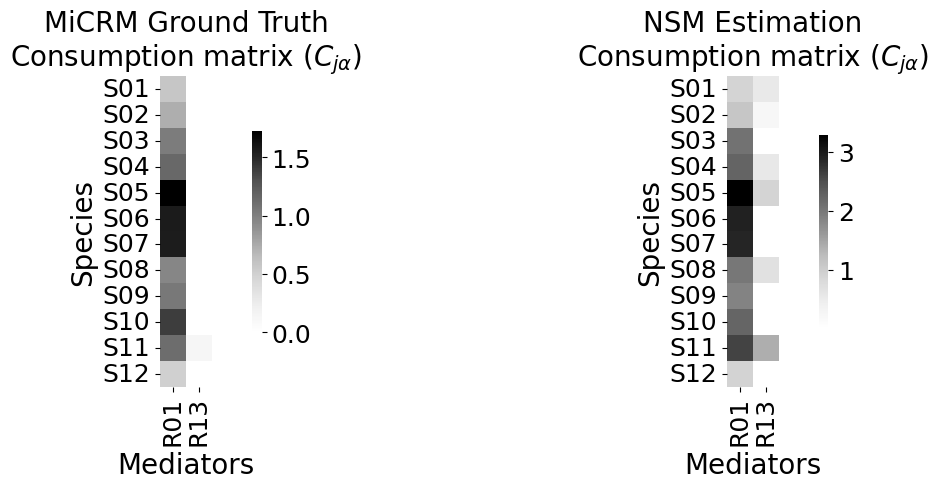

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot MiCRM Ground Truth
to_plot = C_iα.copy()
to_plot = to_plot.loc[species, mediators]
sns.heatmap(to_plot,
            cmap='Greys',
            square=True,
            cbar_kws={"shrink": 0.65},
            ax=axs[0])
axs[0].set_title('MiCRM Ground Truth\nConsumption matrix ($C_{j\\alpha}$)')
axs[0].set_xlabel('Mediators')
axs[0].set_ylabel('Species')

# Plot NSM Estimation
est_C_iα = param_df_summary_c.pivot_table(index='Target', columns='Source', values='Mean').reset_index()
est_C_iα.columns.name = None
est_C_iα.set_index('Target', inplace=True)
est_C_iα.index.name = None
est_C_iα.sort_index(axis=0, inplace=True)
to_plot = est_C_iα.copy()
to_plot = to_plot.loc[species, mediators]
sns.heatmap(to_plot,
            cmap='Greys',
            square=True,
            cbar_kws={"shrink": 0.625},
            ax=axs[1])
axs[1].set_title('NSM Estimation\nConsumption matrix ($C_{j\\alpha}$)')
axs[1].set_xlabel('Mediators')
axs[1].set_ylabel('Species')

plt.tight_layout()
# plt.savefig(f'plots/parameters/values/consumption_matrix_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.svg', dpi=300, bbox_inches='tight')
plt.show()
# plt.close()

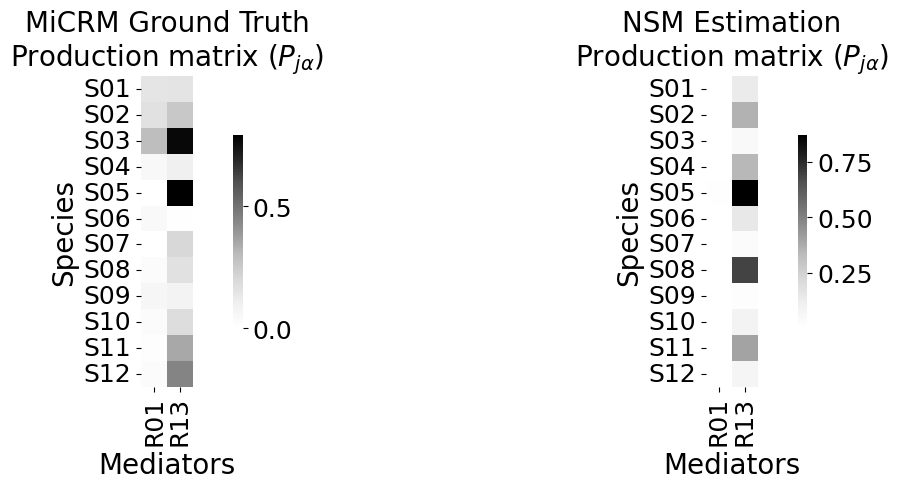

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot MiCRM Ground Truth
to_plot = P_iα.copy()
to_plot = to_plot.loc[species, mediators]
sns.heatmap(to_plot,
            cmap='Greys',
            square=True,
            cbar_kws={"shrink": 0.625},
            ax=axs[0])
axs[0].set_title('MiCRM Ground Truth\nProduction matrix ($P_{j\\alpha}$)')
axs[0].set_xlabel('Mediators')
axs[0].set_ylabel('Species')

# Plot NSM Estimation
est_P_iα = param_df_summary_p.pivot_table(index='Source', columns='Target', values='Mean').reset_index()
est_P_iα.columns.name = None
est_P_iα.set_index('Source', inplace=True)
est_P_iα.index.name = None
est_P_iα.sort_index(axis=0, inplace=True)
to_plot = est_P_iα.copy()
to_plot = to_plot.loc[species, mediators]
sns.heatmap(to_plot,
            cmap='Greys',
            square=True,
            cbar_kws={"shrink": 0.625},
            ax=axs[1])
axs[1].set_title('NSM Estimation\nProduction matrix ($P_{j\\alpha}$)')
axs[1].set_xlabel('Mediators')
axs[1].set_ylabel('Species')

plt.tight_layout()
# plt.savefig(f'plots/parameters/values/production_matrix_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.svg', dpi=300, bbox_inches='tight')
plt.show()
# plt.close()

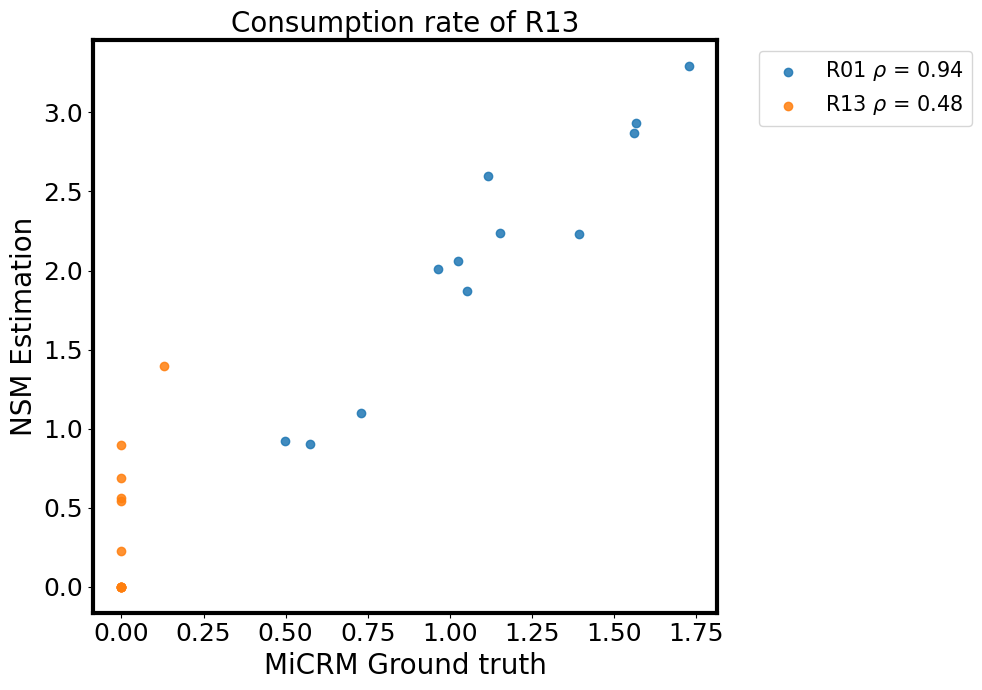

,correlation,Mediator
0,0.944056,R01
1,0.480384,R13


In [16]:
c_params = {}
c_correlations = {
    'correlation': []
}

a_c = param_df_summary_c.pivot_table(index='Target', columns='Source', values='Mean').reset_index()
a_c.columns.name = None
a_c.set_index('Target', inplace=True)
a_c.index.name = None
a_c.sort_index(axis=0, inplace=True)
plt.figure(figsize=(10, 7))
for mediator in a_c.columns:
    correlation, _ = spearmanr(C_iα.loc[:,mediator].values, a_c.loc[:,mediator].values)
    # correlation, _ = pearsonr(c_iα.loc[:,mediator].values, a_c.loc[:,mediator].values)
    c_correlations['correlation'].append(correlation)
    plt.scatter(C_iα[mediator], a_c[mediator], label=f'{mediator} $\\rho$ = {correlation:.2f}', alpha=0.85)
    plt.xlabel('MiCRM Ground truth')
    plt.ylabel('NSM Estimation')
    plt.title(f'Consumption rate of {mediator}')
    # plt.legend([f'$\\rho$ = {correlation:.2f}'], loc=0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.savefig(f'plots/parameters/correlations/consumption_correlation_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k_{mediator}.svg', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
    # plt.close()
c_correlations_df = pd.DataFrame(c_correlations)
c_correlations_df['Mediator'] = a_c.columns
c_correlations_df

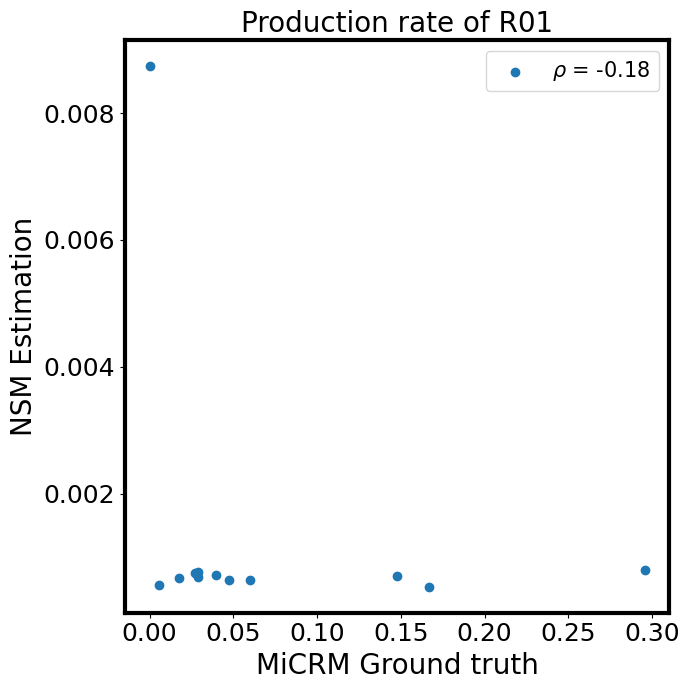

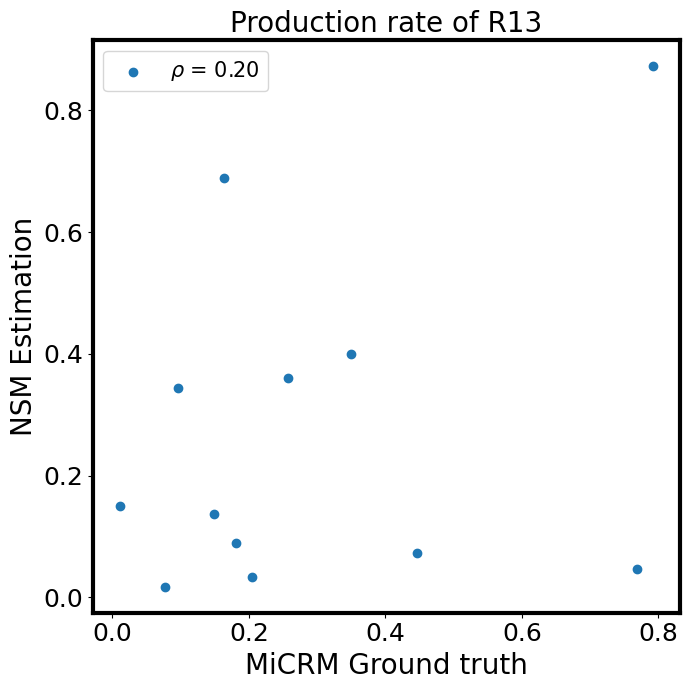

,correlation,Mediator
0,-0.181818,R01
1,0.195804,R13


In [17]:
p_params = {}
p_correlations = {
    'correlation': []
}

a_p = param_df_summary_p.pivot_table(index='Source', columns='Target', values='Mean').reset_index()
a_p.columns.name = None
a_p.set_index('Source', inplace=True)
a_p.index.name = None
a_p.sort_index(axis=0, inplace=True)
for mediator in a_p.columns:
    correlation, _ = spearmanr(P_iα.loc[:,mediator].values, a_p.loc[:,mediator].values)
    # correlation, _ = pearsonr(D_iα.loc[:,mediator].values, a_p.loc[:,mediator].values)
    p_correlations['correlation'].append(correlation)
    plt.scatter(P_iα[mediator], a_p[mediator])
    plt.xlabel('MiCRM Ground truth')
    plt.ylabel('NSM Estimation')
    plt.title(f'Production rate of {mediator}')
    plt.legend([f'$\\rho$ = {correlation:.2f}'], loc=0)
    plt.tight_layout()
    # plt.savefig(f'plots/parameters/correlations/production_correlation_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k_{mediator}.svg', dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close()
p_correlations_df = pd.DataFrame(p_correlations)
p_correlations_df['Mediator'] = a_p.columns
p_correlations_df

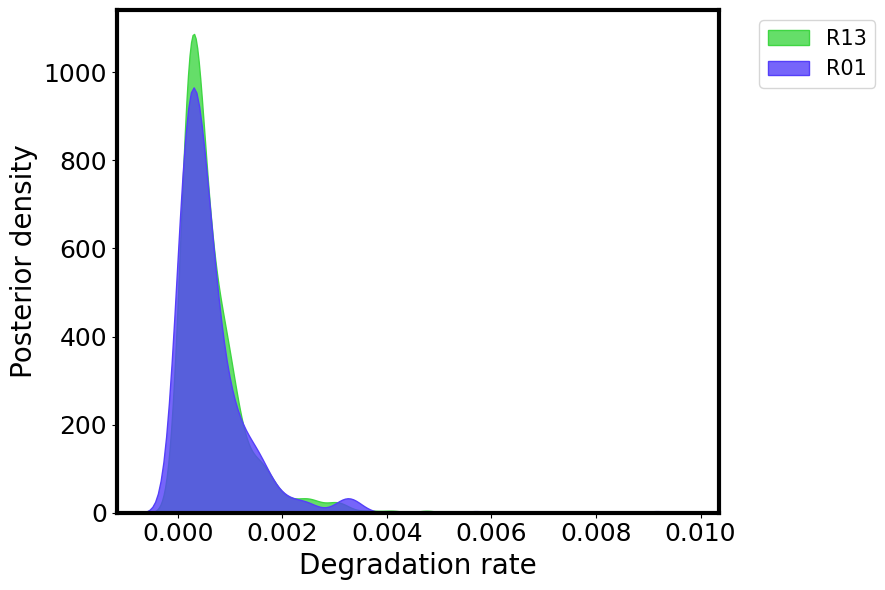

In [18]:
# plot params for every mediator_complexity, experiments combination
# Define a custom color palette with distinct and vibrant colors
custom_colors = distinctipy.get_colors(len(mediators), pastel_factor=0.3)

# Create a dictionary mapping each mediator to a unique color
mediators_color_dict = dict(zip(mediators, custom_colors))

plt.figure(figsize=(9, 6))
param_names = [f'd({md})' for md in mediators]
deg_md = param_df[param_names].values
deg_md_mean = np.mean(deg_md, 0)
md = np.array(mediators)[np.argsort(deg_md_mean)[::-1]]
deg_md_values = deg_md[:, np.argsort(deg_md_mean)[::-1]]

for i in range(len(mediators)):
# for i in range(3):
    sns.kdeplot(deg_md_values[:, i], 
                label=md[i], 
                color=mediators_color_dict[md[i]], 
                fill=True, 
                alpha=0.8
                )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel("Posterior density")
plt.xlabel("Degradation rate")

plt.tight_layout()
plt.show()

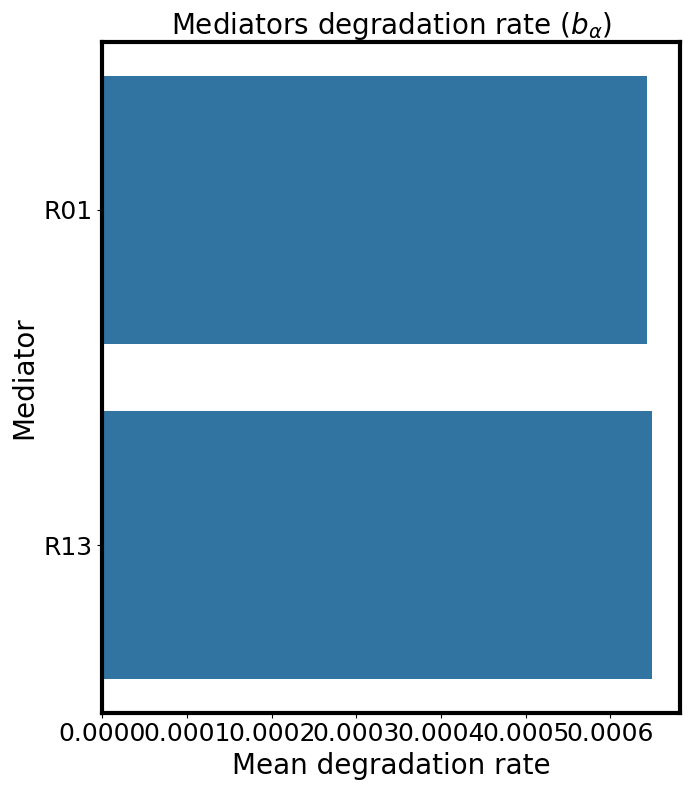

In [19]:
deg_md = param_df[param_names]
deg_md_mean = deg_md.mean()
deg_md_mean
# barplot
plt.figure(figsize=(7, 8))
sns.barplot(y=mediators, x=deg_md_mean)
plt.xlabel('Mean degradation rate')
plt.ylabel('Mediator')
plt.title('Mediators degradation rate ($b_{\\alpha}$)')
plt.tight_layout()
# plt.savefig(f'plots/parameters/values/degradation_rate_{sps}s{rscs}r_{cplx}_{cs}_{exps}exps_{md}_{k}k.svg', dpi=300, bbox_inches='tight')
plt.show()
# plt.close()

In [20]:
def binary_classification(y_true, y_pred, true_threshold=0.5, pred_threshold=0.5):
    """
    Computes the true positive rate, false positive rate, true negative rate, and false negative rate.
    
    Parameters:
    y_true (ndarray): An array of true labels.
    y_pred (ndarray): An array of predicted probabilities.
    true_threshold (float): The classification threshold for true labels.
    pred_threshold (float): The classification threshold for predicted probabilities.
    
    Returns:
    float: The true positive rate.
    float: The false positive rate.
    float: The true negative rate.
    float: The false negative rate.
    """
    # Compute the confusion matrix
    y_pred = y_pred > pred_threshold
    y_true = y_true > true_threshold
    tp = np.sum(y_true & y_pred)
    fp = np.sum(~y_true & y_pred)
    tn = np.sum(~y_true & ~y_pred)
    fn = np.sum(y_true & ~y_pred)
    
    # Compute the rates
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    tnr = tn / (tn + fp)
    fnr = fn / (fn + tp)
    
    return tpr, fpr, tnr, fnr

def plot_roc_curve(y_true, y_pred, true_threshold=0.5, pred_threshold=0.5, param_name='Consumption'):
    """
    Plots the ROC curve for binary classification.
    
    Parameters:
    y_true (ndarray): An array of true labels.
    y_pred (ndarray): An array of predicted probabilities.
    true_threshold (float): The classification threshold for true labels.
    pred_threshold (float): The classification threshold for predicted probabilities.
    """
    # Binarize the true and predicted values
    y_true_bin = y_true > true_threshold
    y_pred_bin = y_pred > pred_threshold
    
    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_true_bin, y_pred_bin)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    # plt.savefig(f'trouble-shooting/roc_{param_name}_{sps}s_{rscs}r_{md_cplx}.svg', dpi=300, bbox_inches='tight')
    plt.show()

True positive rate: 1.00
False positive rate: 0.45
True negative rate: 0.55
False negative rate: 0.00


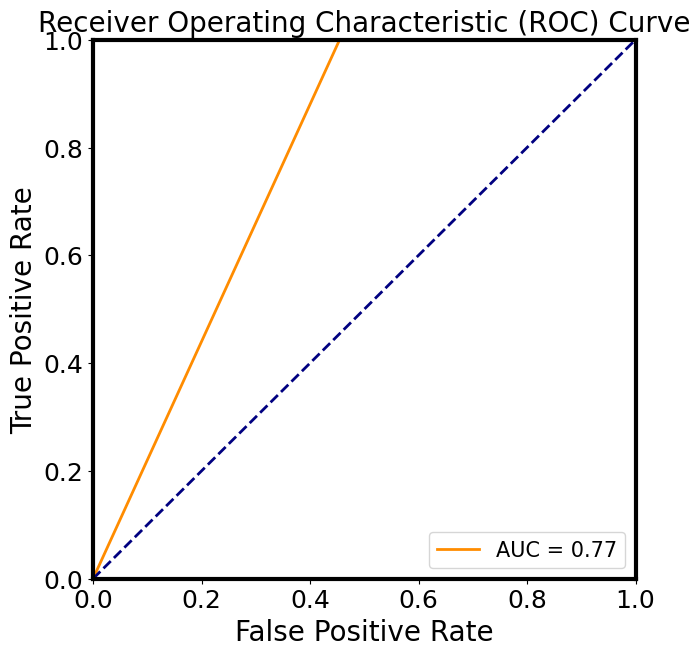

In [21]:
tpr, fpr, tnr, fnr = binary_classification(C_iα.loc[:,mediators].values.flatten(), est_C_iα.values.flatten(), true_threshold=0, pred_threshold=0.1)
print(f'True positive rate: {tpr:.2f}')
print(f'False positive rate: {fpr:.2f}')
print(f'True negative rate: {tnr:.2f}')
print(f'False negative rate: {fnr:.2f}')
plot_roc_curve(C_iα.loc[:,mediators].values.flatten(), est_C_iα.values.flatten(), true_threshold=0, pred_threshold=0.1, param_name='Consumption')

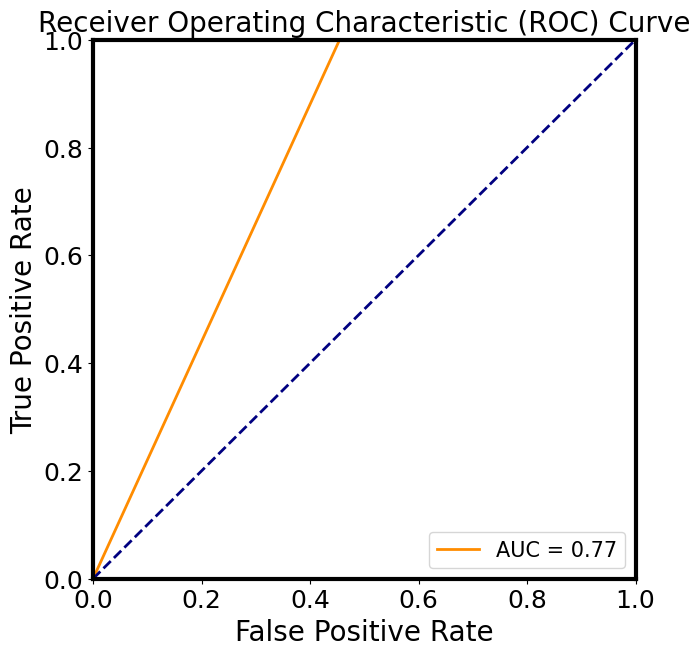

In [22]:
C, C_pvals, P, P_pvals = get_param_stats(model)
C_true_binary = C_iα.values.flatten() > 0

# plot roc curve using C_true_binary and C_pvals (the probabilities)
fpr, tpr, _ = roc_curve(C_true_binary, C_pvals.T.flatten())
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

True positive rate: 1.00
False positive rate: 1.00
True negative rate: 0.00
False negative rate: 0.00


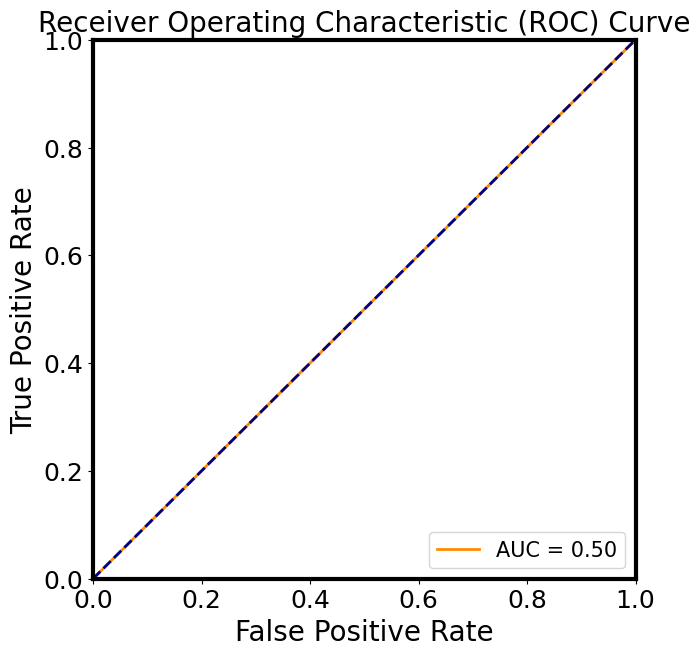

In [23]:
tpr, fpr, tnr, fnr = binary_classification(P_iα.loc[:,mediators].values.flatten(), est_P_iα.values.flatten(), true_threshold=0, pred_threshold=0)
print(f'True positive rate: {tpr:.2f}')
print(f'False positive rate: {fpr:.2f}')
print(f'True negative rate: {tnr:.2f}')
print(f'False negative rate: {fnr:.2f}')
plot_roc_curve(P_iα.loc[:,mediators].values.flatten(), est_P_iα.values.flatten(), true_threshold=0, pred_threshold=0, param_name='Production')

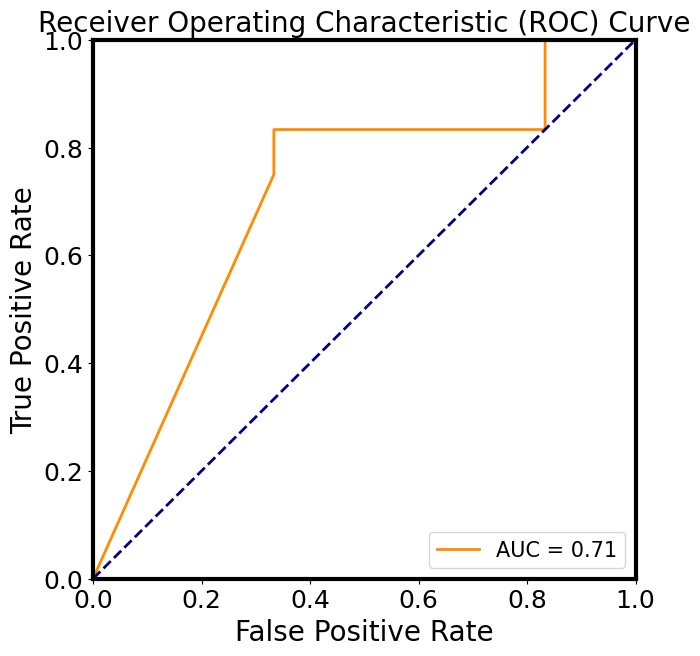

In [24]:
C, C_pvals, P, P_pvals = get_param_stats(model)
P_true_binary = P_iα.loc[:,mediators].values.flatten() > 0.1

# plot roc curve using C_true_binary and C_pvals (the probabilities)
fpr, tpr, _ = roc_curve(P_true_binary, P_pvals.T.flatten())
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
